In [3]:
import numpy as numpy
import pandas as pd
import matplotlib.pyplot as plt
from app.core.config import DATA_DIR

In [47]:
df = pd.read_csv("../../data/raw/PS_20174392719_1491204439457_log.csv")
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [68]:
print("Total Rows : ",len(df))


Total Rows :  6362620


In [69]:
df.notnull().sum()

step                6362620
type                6362620
amount              6362620
nameOrig            6362620
oldbalanceOrg       6362620
newbalanceOrig      6362620
nameDest            6362620
oldbalanceDest      6362620
newbalanceDest      6362620
isFraud             6362620
isFlaggedFraud      6362620
dest_is_repeated    6362620
dtype: int64

In [ ]:
df_filtered_M = df[df['nameDest'].str.startswith('M')]

print(df_filtered_M.duplicated(subset='nameDest').value_counts())

False    2151495
Name: count, dtype: int64


In [94]:
print("Unique nameOrig:", df['nameOrig'].nunique(), "from", len(df), "rows", "As much : ", (df['nameOrig'].nunique() / len(df)) * 100, " %, is a unique trx from dataset")
print("Unique nameDest:", df['nameDest'].nunique(), "from", len(df), "rows", "As much : ", (df['nameDest'].nunique()/ len(df)) * 100, " %, is a unique trx  from dataset")

print("\nDistribusi nameDest emergence:")
print(df['nameDest'].value_counts().value_counts().sort_index())

Unique nameOrig: 6353307 from 6362620 rows As much :  99.85362947967975  %, is a unique trx from dataset
Unique nameDest: 2722362 from 6362620 rows As much :  42.78680795018404  %, is a unique trx  from dataset

Distribusi nameDest emergence:
count
1      2262704
2        77054
3        57289
4        45115
5        36821
        ...   
101          2
102          1
105          1
109          1
113          1
Name: count, Length: 101, dtype: int64


In [96]:
# dest_counts = df['nameDest'].value_counts()
# df['dest_is_repeated'] = df['nameDest'].map(dest_counts) > 5

# print(df.groupby('dest_is_repeated')['isFraud'].mean())

# fraud_dest_counts = df[df['isFraud']==1]['nameDest'].map(dest_counts)
# print(fraud_dest_counts.describe())

df_risky = df[df['type'].isin(["TRANSFER","CASH_OUT"])].copy()

dest_counts_risky = df_risky['nameDest'].value_counts()
df_risky['dest_is_repeated'] = df_risky['nameDest'].map(dest_counts_risky) > 5

# print(dest_counts_risky)
print(df_risky.groupby('dest_is_repeated')['isFraud'].mean())

dest_is_repeated
False    0.006857
True     0.001388
Name: isFraud, dtype: float64


In [72]:
df_risky = df_risky.sort_values('step').reset_index(drop=True)

df_risky['dest_txn_count_so_far'] = df_risky.groupby('nameDest').cumcount()

df_risky['is_new_destination'] = (df_risky['dest_txn_count_so_far'] == 0).astype(int)

In [ ]:
sample_dest = df_risky['nameDest'].value_counts().index[0]  

cols_to_check = ['step', 'nameDest', 'amount', 'isFraud', 'dest_txn_count_so_far', 'is_new_destination']
print(df_risky[df_risky['nameDest'] == sample_dest][cols_to_check])

         step     nameDest       amount  isFraud  dest_txn_count_so_far  \
75          1  C1286084959     16626.81        0                      0   
93          1  C1286084959    789419.02        0                      1   
224         1  C1286084959    432168.02        0                      2   
247         1  C1286084959    138647.54        0                      3   
274         1  C1286084959    607537.17        0                      4   
...       ...          ...          ...      ...                    ...   
1754648   299  C1286084959  21300322.58        0                     70   
2106507   346  C1286084959     84205.39        0                     71   
2116919   347  C1286084959    235564.75        0                     72   
2447510   394  C1286084959    381887.53        0                     73   
2537513   401  C1286084959    189251.84        0                     74   

         is_new_destination  
75                        1  
93                        0  
224      

In [86]:
fraud_destinations = df_risky[df_risky['isFraud'] == 1]['nameDest'].unique()
appearance_after = df_risky[df_risky['nameDest'].isin(fraud_destinations)]['nameDest'].value_counts()
print(appearance_after.describe())
print("\nBerapa % destinasi fraud yang MUNCUL LAGI setelahnya:")
print((appearance_after > 1).mean())

count    8169.000000
mean        5.656261
std         6.778455
min         1.000000
25%         1.000000
50%         3.000000
75%         8.000000
max        56.000000
Name: count, dtype: float64

Berapa % destinasi fraud yang MUNCUL LAGI setelahnya:
0.6202717590892398


In [93]:
repeated_fraud_dest = appearance_after[appearance_after > 1].index

subsequent_txns = df_risky[df_risky['nameDest'].isin(repeated_fraud_dest)]
print(subsequent_txns.groupby('nameDest')['isFraud'].agg(['sum', 'count']))

print("\nFraud rate pada akun yang berulang (dari SEMUA transaksi mereka):")
# print(repeated_fraud_dest)
print(subsequent_txns['isFraud'].mean())
print(subsequent_txns.groupby('nameDest')['isFraud'].sum().value_counts())

             sum  count
nameDest               
C1000039615    1      2
C1001258143    1      7
C1002031672    1     25
C1002183297    1      5
C1002469873    1     24
...          ...    ...
C997789760     1      2
C998024073     1      5
C998349190     1      5
C999409522     1      5
C999708230     1      2

[5067 rows x 2 columns]

Fraud rate pada akun yang berulang (dari SEMUA transaksi mereka):
0.11857368225686711
isFraud
1    5023
2      44
Name: count, dtype: int64


In [ ]:
print(df[df['nameDest'].str.startswith('M')][['oldbalanceOrg','newbalanceDest']].describe())

       oldbalanceOrg  newbalanceDest
count   2.151495e+06       2151495.0
mean    6.821683e+04             0.0
std     1.989911e+05             0.0
min     0.000000e+00             0.0
25%     0.000000e+00             0.0
50%     1.053000e+04             0.0
75%     6.088300e+04             0.0
max     4.368662e+07             0.0


In [22]:
print(df[df['nameDest'].str.startswith('M')][['oldbalanceOrg','newbalanceDest']].describe())

       oldbalanceOrg  newbalanceDest
count   2.151495e+06       2151495.0
mean    6.821683e+04             0.0
std     1.989911e+05             0.0
min     0.000000e+00             0.0
25%     0.000000e+00             0.0
50%     1.053000e+04             0.0
75%     6.088300e+04             0.0
max     4.368662e+07             0.0


In [26]:
print("Fraud : ",df[df['isFraud']==1]['type'].value_counts())
print("No Fraud : ",df[df['isFraud']==0]['type'].value_counts())

Fraud :  type
CASH_OUT    4116
TRANSFER    4097
Name: count, dtype: int64
No Fraud :  type
CASH_OUT    2233384
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     528812
DEBIT         41432
Name: count, dtype: int64


In [28]:
print("Check if there's a fraud on the other types : ",df[~df['type'].isin(['CASH_OUT','PAYMENT'])]['isFraud'].sum()==0)

Check if there's a fraud on the other types :  False


# Checking Imbalance CLass

In [6]:
print("Normalize : ",df['isFraud'].value_counts(normalize=True))
print("Exact Value : ",df['isFraud'].value_counts())

Normalize :  isFraud
0    0.998709
1    0.001291
Name: proportion, dtype: float64
Exact Value :  isFraud
0    6354407
1       8213
Name: count, dtype: int64


<small>

### 📊 Conclusion
From that result we can conclude that on this dataset, we cannot using Accuracy as a metric evaluation because it make our model bias. Instead we gonna use Recall,Precision or F1-Score

</small>


In [67]:
risk_df = df[df['type'].isin(['TRANSFER','CASHOUT'])].copy()
print("Normalize : ",risk_df['isFraud'].value_counts(normalize=True))
print("Exact Value : ",risk_df['isFraud'].value_counts())
# (4097 / len(risk_df)) * 100
# (528812 / len(risk_df)) * 100

Normalize :  isFraud
0    0.992312
1    0.007688
Name: proportion, dtype: float64
Exact Value :  isFraud
0    528812
1      4097
Name: count, dtype: int64


In [7]:
df.duplicated().sum()

0

In [8]:
df.describe()
# df['amount'].mean() > df['amount'].median() #True

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [9]:
df[df['oldbalanceOrg'] == 0].value_counts().sum()

2102449

In [10]:
df[['amount', 'oldbalanceOrg', 'newbalanceOrig']].skew()

amount            30.993949
oldbalanceOrg      5.249136
newbalanceOrig     5.176884
dtype: float64

Right Skew

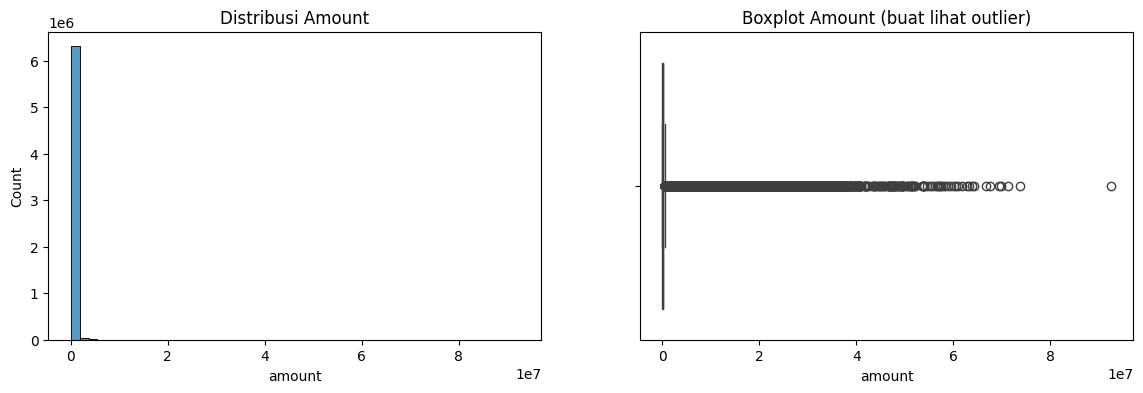

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df['amount'], bins=50, ax=axes[0])
axes[0].set_title('Distribusi Amount')

sns.boxplot(x=df['amount'], ax=axes[1])
axes[1].set_title('Boxplot Amount (buat lihat outlier)')
plt.show()

In [12]:
fraud_df = df[df['isFraud'] == 1]
nonfraud_df = df[df['isFraud'] == 0]

print("Fraud - % oldbalanceDest == 0:", (fraud_df['oldbalanceDest'] == 0).mean())
print("Non-fraud - % oldbalanceDest == 0:", (nonfraud_df['oldbalanceDest'] == 0).mean())

print("Fraud - % newbalanceDest == 0:", (fraud_df['newbalanceDest'] == 0).mean())
print("Non-fraud - % newbalanceDest == 0:", (nonfraud_df['newbalanceDest'] == 0).mean())

Fraud - % oldbalanceDest == 0: 0.6515280652623889
Non-fraud - % oldbalanceDest == 0: 0.4247504133745289
Fraud - % newbalanceDest == 0: 0.49811274808230854
Non-fraud - % newbalanceDest == 0: 0.38325244196665403


In [13]:
df['errorBalanceOrig'] = df['oldbalanceOrg'] - df['amount'] - df['newbalanceOrig']
df['errorBalanceDest'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']

# Bandingin distribusi error ini antara fraud vs bukan
print(df.groupby('isFraud')[['errorBalanceOrig', 'errorBalanceDest']].describe())

        errorBalanceOrig                                             \
                   count           mean            std          min   
isFraud                                                               
0              6354407.0 -201338.558109  606928.890826 -92445516.64   
1                 8213.0  -10692.325265  265146.131130 -10000000.00   

                                                     errorBalanceDest  \
               25%       50%       75%           max            count   
isFraud                                                                 
0       -249953.43 -69049.31 -3034.305  1.000000e-02        6354407.0   
1             0.00      0.00     0.000  3.725290e-09           8213.0   

                                                                             \
                  mean           std          min  25%      50%         75%   
isFraud                                                                       
0         54692.231734  4.360026e+05 -758